[6.09536672e-01 8.68929260e-01 5.13909465e-01 7.79089383e-01
 9.53723656e-01 5.23451932e-02 2.27636761e-01 7.89347054e-01
 7.37037455e-01 3.12417654e-01 9.66424758e-01 6.70829492e-01
 4.08948143e-03 4.99306936e-01 7.19672711e-01 1.79605592e-01
 6.44589971e-02 9.51291957e-01 8.87630911e-01 4.78687093e-01
 9.94347672e-01 2.55081828e-01 5.14401674e-02 1.02764693e-01
 9.78692448e-01 4.51196086e-03 9.99621703e-01 9.37634035e-01
 1.18188476e-02 9.69791848e-01 8.68816110e-01 9.88422095e-01
 6.15473106e-01 1.47860299e-01 3.12980543e-01 1.65110252e-01
 7.00945658e-02 4.04964522e-01 4.55256562e-02 2.76558176e-01
 1.86227131e-02 9.48312870e-01 5.57726753e-02 4.53793669e-01
 5.01184326e-01 1.14111255e-02 9.92328859e-01 5.41306342e-03
 8.59704303e-01 9.90278194e-01 7.62490429e-02 7.65075587e-02
 1.00222414e-02 9.96565652e-01 9.96836896e-01 6.70517119e-01
 1.45131996e-02 7.91753836e-02 8.06830161e-01 1.68324514e-01
 7.66609556e-01 1.29896275e-01 9.83767858e-02 9.99678950e-01
 9.99478943e-01 4.951586

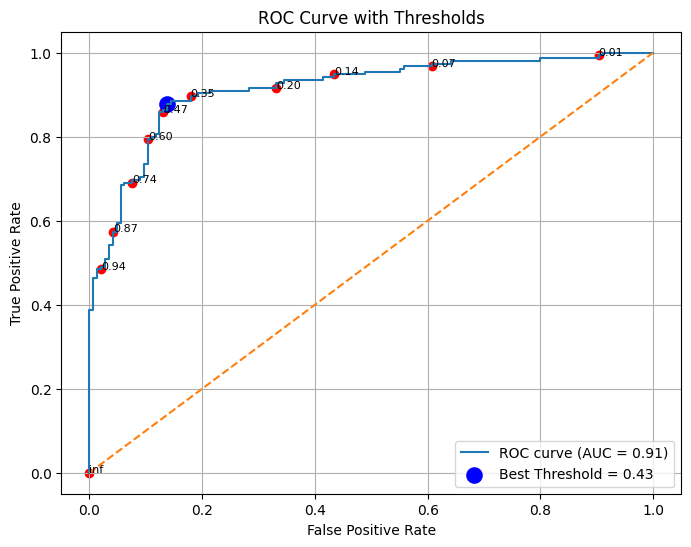

In [1]:
# Import libraries
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np

# Generate dataset
X, y = make_classification(n_samples=1000, n_classes=2, random_state=42)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Train model
model = LogisticRegression()
model.fit(X_train, y_train)

# Probabilities
y_probs = model.predict_proba(X_test)[:, 1]
print(y_probs)

# ROC + AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

print("AUC Score:", roc_auc)

# Find best threshold (Youden's J)
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]

print("Best Threshold:", best_threshold)

# Apply best threshold
y_pred_custom = (y_probs >= best_threshold).astype(int)

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_custom))
print("\nClassification Report:\n", classification_report(y_test, y_pred_custom))

# Plot ROC
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--')

# Mark threshold points (avoid divide-by-zero bug)
step = max(1, len(thresholds)//10)
for i in range(0, len(thresholds), step):
    plt.scatter(fpr[i], tpr[i], color='red')
    plt.text(fpr[i], tpr[i], f"{thresholds[i]:.2f}", fontsize=8)

# Highlight best threshold
plt.scatter(fpr[best_idx], tpr[best_idx], color='blue', s=120,
            label=f"Best Threshold = {best_threshold:.2f}")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve with Thresholds")
plt.legend(loc="lower right")
plt.grid()
plt.show()